## Using LLM to extract answers script

Author: Sahana Kowshik

Date: 05/07/2025

In [2]:
# data = pd.read_csv('/projectnb/vkolagrp/datasets/NACC/csv/raw/investigator_ftldlbd_nacc65.csv')
# data_json = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/NACC_wjson.csv")
# train = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/training_data_grpo/train_summary.csv")
# test = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv")
# test_np = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_np.csv")

In [1]:
# set(train['ID']).intersection(set(model_dfs['qwen3b']['ID']))
# len(data) == len(data_json)
# len(data[data['NACCUDSD'] != 2]['NACCID'].unique())
# len(data_json[data_json['NACCUDSD'] != 2]['NACCID'].unique())
# len(train) + len(test) == len(data_json[data_json['NACCUDSD'] != 2]['NACCID'].unique())
# set(train['ID']).intersection(set(test['NACCID']))

In [1]:
import os
os.environ['HF_HOME'] = '/projectnb/vkolagrp/skowshik/.cache/'
import torch
import torch.nn.functional as F
import argparse
import pandas as pd
import numpy as np
import torch.distributed as dist
import json
import warnings
import random
import time
import string
warnings.filterwarnings("ignore")
import re

from tqdm import tqdm
from datetime import timedelta
from collections import OrderedDict
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams
os.environ['VLLM_SKIP_P2P_CHECK'] = "1"

INFO 05-24 16:30:27 [__init__.py:239] Automatically detected platform cuda.


In [2]:
x = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/select_train_cases/all_correct.csv")

In [9]:
# print(x.iloc[0]['patient_summary'])
# print(x.iloc[0]['visit_summary'])

In [2]:
# model_id = 'Qwen/Qwen2.5-14B-Instruct'
model_id = 'Qwen/Qwen3-8B'
n_devices = 2
max_model_len = 10000

In [8]:
# max_len = 0
# len_2k = []
# for i, row in data.iterrows():
#     cur_len = len(tokenizer.encode(row["visit_summary"]))
#     max_len = max(max_len, cur_len)
#     if cur_len == 2000:
#         len_2k.append(i)

In [9]:
# max_len

In [10]:
def load_model(model_id, n_devices, max_model_len):
    """Load VLLM model and Huggingface tokenizer."""
    llm = LLM(
        model=model_id,
        tokenizer=model_id,
        tensor_parallel_size=n_devices,
        gpu_memory_utilization=0.9,
        max_model_len=max_model_len,
        enable_lora=False,
        distributed_executor_backend='mp',
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    return llm, tokenizer

In [11]:
llm, tokenizer = load_model(model_id, n_devices, max_model_len)

INFO 05-20 14:00:13 [config.py:717] This model supports multiple tasks: {'embed', 'generate', 'score', 'classify', 'reward'}. Defaulting to 'generate'.
INFO 05-20 14:00:13 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-20 14:00:16 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen3-8B', speculative_config=None, tokenizer='Qwen/Qwen3-8B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=10000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, collec

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  20% Completed | 1/5 [00:01<00:06,  1.60s/it]
Loading safetensors checkpoint shards:  40% Completed | 2/5 [00:08<00:13,  4.57s/it]
Loading safetensors checkpoint shards:  60% Completed | 3/5 [00:16<00:12,  6.31s/it]
Loading safetensors checkpoint shards:  80% Completed | 4/5 [00:24<00:06,  6.93s/it]


(VllmWorker rank=1 pid=1284034) INFO 05-20 14:00:55 [loader.py:458] Loading weights took 32.64 seconds
(VllmWorker rank=1 pid=1284034) INFO 05-20 14:00:56 [gpu_model_runner.py:1347] Model loading took 7.6394 GiB and 33.991357 seconds


Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:32<00:00,  7.46s/it]
Loading safetensors checkpoint shards: 100% Completed | 5/5 [00:32<00:00,  6.58s/it]
(VllmWorker rank=0 pid=1284033) 


(VllmWorker rank=0 pid=1284033) INFO 05-20 14:00:56 [loader.py:458] Loading weights took 32.95 seconds
(VllmWorker rank=0 pid=1284033) INFO 05-20 14:00:56 [gpu_model_runner.py:1347] Model loading took 7.6394 GiB and 34.380309 seconds
(VllmWorker rank=0 pid=1284033) (VllmWorker rank=1 pid=1284034) INFO 05-20 14:01:19 [backends.py:420] Using cache directory: /usr3/graduate/skowshik/.cache/vllm/torch_compile_cache/6a2d52fc2f/rank_0_0 for vLLM's torch.compile
INFO 05-20 14:01:19 [backends.py:420] Using cache directory: /usr3/graduate/skowshik/.cache/vllm/torch_compile_cache/6a2d52fc2f/rank_1_0 for vLLM's torch.compile
(VllmWorker rank=1 pid=1284034) (VllmWorker rank=0 pid=1284033) INFO 05-20 14:01:19 [backends.py:430] Dynamo bytecode transform time: 23.36 s
INFO 05-20 14:01:19 [backends.py:430] Dynamo bytecode transform time: 23.36 s
(VllmWorker rank=0 pid=1284033) (VllmWorker rank=1 pid=1284034) INFO 05-20 14:01:26 [backends.py:136] Cache the graph of shape None for later use
INFO 05-20 1

In [3]:
def get_vllm_summary(llm, tokenizer, messages, max_new_tokens=3000):
    """This is a function to generate LLAMA summaries using vllm https://github.com/vllm-project/vllm

    Args:
        llm: LLM object
        tokenizer: Huggingface tokenizer
        input_texts (List): A list of input texts / prompts
        system_msg (str): system message for the LLAMA prompt

    Returns:
        List: A list of generated responses
    """
    
    # return "Answer"
    

    prompts = []
    responses = []
    
    for message in messages:
        input_ids = tokenizer.apply_chat_template(
            message,
            add_generation_prompt=True,
            tokenize=False,
            continue_final_message=False,
            enable_thinking=False
            # return_tensors="pt"
        )
        
        prompts.append(input_ids)
    
    # https://github.com/vllm-project/vllm/blob/main/vllm/sampling_params.py#L38-L66
    sampling_params = SamplingParams(
        temperature=0.7,
        top_p=0.8,
        top_k=20,
        min_p=0,
        max_tokens=max_new_tokens,
        # frequency_penalty=0.5,
        # stop=stop_tokens
    )
    
    completions = llm.generate(
        prompts=prompts,
        sampling_params=sampling_params,
    )
    
    for i, output in enumerate(completions):
        temp_gen = output.outputs[0].text
        responses.append(temp_gen)
        
    # print('Successfully finished generating', len(prompts), 'samples!')
    
    return responses

In [4]:
def generate_summary(answers_dicts, llm, tokenizer, max_new_tokens=2048):
    """
    Generate summaries for patient data using a language model.
    
    Args:
    - patient_files: List of strings containing JSON-encoded patient data.
    - system_msg: Initial system message for the language model.
    - llm, tokenizer: Language model and tokenizer for generating summaries.

    Returns:
    - List of patient summaries.
    """
    messages = []
    for answers_dict in answers_dicts:
        message = [
            # {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
            {"role": "user", "content": EXTRACT_ANSWER_PROMPT.format(answer=answers_dict['answer'], question=answers_dict['question'], option=answers_dict['option'])}
        ]
        messages.append(message)
        
    extracted_answers = get_vllm_summary(llm, tokenizer, messages, max_new_tokens=max_new_tokens)
    
    return extracted_answers

In [5]:
def extract_answer_letter(text):
    """
    Extracts the single-letter answer from a string in the format 'ANSWER: X'.

    Args:
        text (str): Input string, e.g., 'ANSWER: B'

    Returns:
        str or None: Extracted answer letter, or None if no match is found.
    """
    match = re.search(r'ANSWER:\s*([A-Z])', text)
    if match:
        return match.group(1)
    return None

In [6]:
def extract_naccid(row):
    naccid = row['problem']['ID']
    row['ID'] = naccid
    return row

def load_results(file_path):
    results = []

    with open(file_path,'r') as f:
        for line in f:
            results.append(json.loads(line))

    results_df = pd.DataFrame(results).explode(['generated_text','finish_reason'])
    results_df = results_df.apply(extract_naccid, axis=1)
    results_df['UNQ_ID'] = [i for i in range(len(results_df))]
    
    return results_df

In [7]:
re.search(r'<answer>.*\s*(Answer: )([a-zA-Z])\s+</answer>', "<answer>\nAnswer: D \n</answer>", re.DOTALL)

<re.Match object; span=(0, 29), match='<answer>\nAnswer: D \n</answer>'>

In [8]:
re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', "<answer>\nAnswer: D \n</answer>", re.DOTALL)

In [9]:
# def extract_final_answer(text):
#     # match = re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', text, re.DOTALL)
#     # match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z]).*\s*</answer>', text, re.DOTALL)
#     # match = re.search(r'</think>.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
#     return match.group(2).strip().upper() if match else 'invalid'

# def extract_final_answer_full_text(text):
#     match = re.search(r'.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
#     return match.group(2).strip().upper() if match else 'invalid'

def extract_final_answer_with_answer_tag(text):
    match = re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', text, re.DOTALL)
    # match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z]).*\s*</answer>', text, re.DOTALL)
    # match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z])\s+</answer>', text, re.DOTALL)
    # match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z])\.*\s+.*\s*</answer>', text, re.DOTALL)
    return match.group(2).strip().upper() if match else 'invalid'

def extract_final_answer_qwen3(text):
    match = re.search(r'</think>.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
    return match.group(2).strip().upper() if match else 'invalid'

def extract_answers_regex(results_df, name, option_keys):
    if "qwen3" in name:
        results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer_qwen3)
    else:
        results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer_with_answer_tag)
        
    # results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer_with_answer_tag)
        
    results_df['ground_truth'] = [p['ground_truth'] for p in results_df.problem]
    results_df['prediction'] = results_df['prediction']#.replace({'N':'B','Y':'A'})
    invalid_list[name] = results_df[(results_df['prediction'] == 'invalid')]
    invalid_before[name] = len(results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))])
    results_df = results_df[(results_df['prediction'] != 'invalid') & (results_df['prediction'].isin(option_keys))].reset_index(drop=True)
    results_df.index = results_df.groupby('ID', sort=False).ngroup()
    return results_df

def extract_answers_regex_llm(results_df, name, option_keys):
    results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer_with_answer_tag)
    invalid_df = results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))].reset_index(drop=True)
    invalid_df['extraction_type'] = "llm"
    valid_df = results_df[~results_df['UNQ_ID'].isin(invalid_df['UNQ_ID'])].reset_index(drop=True)
    valid_df['extraction_type'] = "regex"
    # valid_df['ground_truth'] = [p['answer'] for p in valid_df.problem]
    # valid_df.index = valid_df.groupby('NACCID', sort=False).ngroup()
    # return valid_df
    assert len(valid_df) + len(invalid_df) == len(results_df)
    
    invalid_before[name] = len(invalid_df)
    options = [options_list for _ in range(len(invalid_df))]
    answers = list(invalid_df['generated_text'])
    questions = [problem['question'] for problem in list(invalid_df['problem'])]
    answer_dicts = [
        {
            'answer': answers[i],
            'option': options[i],
            'question': questions[i]
        } for i in range(len(invalid_df))
    ]
    extracted_answers = generate_summary(answer_dicts, llm, tokenizer, max_new_tokens=100)
    extracted_answer_letters = [extract_answer_letter(answer) for answer in extracted_answers]
    # extracted_answer_letters = [answer if answer != 'D' else 'invalid' for answer in extracted_answer_letters]
    invalid_df['prediction'] = extracted_answer_letters
    llm_answers[name] = extracted_answers
    
    results_df = pd.concat([valid_df, invalid_df], axis=0).sort_values(by='ID').reset_index(drop=True)
    # invalid_after[name] = len(results_df[results_df['prediction'] == 'invalid'])
    # results_df = results_df[results_df['prediction'] != 'invalid'].reset_index(drop=True)
    results_df['ground_truth'] = [p['ground_truth'] for p in results_df.problem]
    results_df.index = results_df.groupby('ID', sort=False).ngroup()
    return results_df

In [10]:
def modify(results_df):
    
    results_combined = results_df.copy()[['prediction','ground_truth', 'ID']]
    results_combined['prediction'] = results_combined['prediction']#.replace({'Y': 'A', 'N': 'B'})
    # results_combined['ground_truth'] = results_combined['ground_truth']#.replace({'Yes': 'A', 'No': 'B'})
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    # p = len(results_combined) // n
    # results_combined['run'] = list(range(1,p+1))*n
    results_combined = results_combined.reset_index(names=['problem']).reset_index(drop=True)
    return results_combined

In [11]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    print(n)
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

In [12]:
def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n

def combine_results(results_dict, n, k):
    final_dict = {'metric': ['pass@1', 'cons@k']}
    for key, v in results_dict.items():
        # final_dict[k] = [get_passat1(v), get_consat5(v)]
        # print(get_passat1(v), get_consat5(v))
        p = len(v) // n
        final_dict[key] = [pass_at_k(v, p, k), get_consatk(v, n)]

    # Create a tidy DataFrame
    df = pd.DataFrame(final_dict)
    
    return df

In [13]:
def get_mean_length(df):
    lengths = []
    for i, row in df.iterrows():
        lengths.append(len(row['generated_text'].split(" ")))
        
    return sum(lengths) / len(lengths)

In [14]:
EXTRACT_ANSWER_PROMPT = """You will be given a response enclosed within <response> and </response> tags. Your task is to extract the final answer that matches one of the options listed between <options> and </options>, based on the question provided between <question> and </question>. Do not interpret or infer beyond the provided text. Return your answer strictly in this format: ANSWER: <option letter>. Do not output anything else.

<response>
{answer}
</response>

<question>
{question}
</question>

<options>
{option}
</options>"""


# options_list = """A: Normal Cognition
# B: Mild Cognitive Impairment
# C: Dementia
# D. Cannot extract answer from the text"""

# options_list = """A. Yes
# B. No"""

## Testing data

In [15]:
test_data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv")
test_data_summary = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/with_summary/test_np.csv")

In [16]:
# # Cognitive status
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T140716_5638ab7bf30348dc/qwen3b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T142754_d312720a3a5546cf/qwen7b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-02T174533_216ed996d0334af6/qwen3b_drgrpo_10_adrd_cog_status_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T120511_35a285cb681242d5/qwen3b_drgrpo_summary_10_nocop_adrd_cog_status_summary_output.jsonl"
# # qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T185603_d14d6a8f061b414c/adrd_cog_status_summary_output.jsonl"
# qwen3_4b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-04-30T115311_4b06304f8e094283/qwen3_4b_adrd_cog_status_output.jsonl"

# n = 1000

# # Neuropath
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T153251_46ea2c464e024ff1/qwen3b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-07T155033_4ed00f4cdb084a8a/qwen7b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T143454_8d5208c661114392/qwen3b_drgrpo_10_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results/2025-05-05T141935_217d6e5b857740aa/qwen3b_drgrpo_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# n = 1000

In [17]:
# qwen3_4b
# cognitive status
# qwen3_4b_results_path_t_06 = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-09T114310_83c704e508a54ca9/test_cog_output.jsonl'
# qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-10T132709_5a1efe0f93ce4b10/test_cog_output.jsonl'
# qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-09T192559_8d20a6d517dc43b7/test_cog_output.jsonl'
# n = 1000


# neuropath
# qwen3_4b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_np/2025-05-09T135430_c9cc09cecdad4473/test_np_output.jsonl"
# qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_np/2025-05-09T180847_f6a21216d3a4436d/test_np_output.jsonl'
# n = 1000

# etpr
# qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_etpr/2025-05-09T202811_92ca88c633904b8f/test_etpr_output.jsonl'
# qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_etpr/2025-05-09T214112_977157e935d64c7d/test_etpr_output.jsonl'
# n = 1000

# mci
# qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_mci/2025-05-10T160628_e68173ec76054527/test_mci_output.jsonl'
# qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_mci/2025-05-10T165152_a486533aad6b402f/test_mci_output.jsonl'
# n = 1000

# qwen2.5 3b
# cognitive status
# qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-09T225200_cb2d26a45f0e4976/test_cog_output.jsonl"
# qwen3b_results_path_old_template = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-10T130848_9101e06546c24946/test_cog_output.jsonl"
# qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-10T111609_11d51961d7d54875/test_cog_output.jsonl"

# qwen7b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_cog/2025-05-10T180924_1c0f7a5bda344e90/test_cog_output.jsonl"
# neuropath
# qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_np/2025-05-10T114822_a4624d6b5f914a11/test_np_output.jsonl"
# qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_np/2025-05-10T122630_9aab2838cc8b4750/test_np_output.jsonl"

# etpr
# qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_etpr/2025-05-10T120709_a4f27f1e86144a92/test_etpr_output.jsonl"
# qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_etpr/2025-05-10T124531_757704cab0a941c1/test_etpr_output.jsonl"

# mci
# qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_mci/2025-05-10T151758_8ca921d102694437/test_mci_output.jsonl"
# qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_new/test_mci/2025-05-10T153449_5ff8f1e5f4194655/test_mci_output.jsonl"

In [18]:
# # n = 1000

# # qwen3_4b
# # cognitive status
# # qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-12T134528_cdf8b05450534121/test_cog_output.jsonl'
# # qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-13T185028_3897f805c3214c1d/test_cog_output.jsonl'

# # neuropath
# # qwen3_4b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-12T142058_f008b4d84cd3466a/test_np_output.jsonl"
# # qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-13T192527_39e4ef99c7114d9f/test_np_output.jsonl'

# # etpr
# # qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_etpr/2025-05-12T152427_6468740539f5430e/test_etpr_output.jsonl'
# # qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_etpr/2025-05-13T202944_ff439b98421e405a/test_etpr_output.jsonl'

# # mci
# # qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_mci/2025-05-12T161930_2c086041ef524ee2/test_mci_output.jsonl'
# # qwen3_4b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_mci/2025-05-13T212506_766ab5c851c34963/test_mci_output.jsonl'

# # qwen2.5 3b
# # cognitive status
# # qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-12T103206_7c70f1ebd0564ab6/test_cog_output.jsonl"
# # qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-12T113612_a689fdc3905942ab/test_cog_output.jsonl"
# # qwen3b_drgrpo_results_path_selected = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-14T102037_7b9a0add95c24211/test_cog_output.jsonl"

# # neuropath
# # 1000 cases
# # qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-12T104742_ff588505b7884d1e/test_np_output.jsonl"
# # qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-12T115200_b3cccc8b567d4469/test_np_output.jsonl"
# # qwen3b_drgrpo_results_path_selected = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T102959_949a6ce3c590483e/test_np_output.jsonl"

# # all cases
# qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T120903_66b9abb12f994a55/test_np_output.jsonl"
# qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T134203_7889dfbd9d2248b8/test_np_output.jsonl"


# qwen3b_drgrpo_results_path_selected = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T161034_e68454cb1ec14c7c/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_cont = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T173914_43e267892eff4a5a/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_cont_lr_1e7 = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T185401_aacb12816a024788/test_np_output.jsonl"


# qwen3b_drgrpo_results_path_selected_wait_okay = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T075844_19284013be514e94/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_wait_okay_cont = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T111120_24e01174f88d4f09/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_wait_okay_add_okay = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T201218_c23bf050148d4f8b/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_wait_okay_cont_add_okay = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T210516_607bd8f2f9434b17/test_np_output.jsonl"

# qwen3b_drgrpo_results_path_selected_wait = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-18T040113_91f5cedf56924d1d/test_np_output.jsonl"
# qwen3b_drgrpo_results_path_selected_wait_cont = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-18T055022_ba13620fee31458a/test_np_output.jsonl"


# # etpr
# # qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_etpr/2025-05-12T110641_8b119f8e44ce436f/test_etpr_output.jsonl"
# # qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_etpr/2025-05-12T121059_41a93985ebd84ab8/test_etpr_output.jsonl"
# # qwen3b_drgrpo_results_path_1900 = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_etpr/2025-05-12T131532_9a499854d53f4932/test_etpr_output.jsonl"

# # mci
# # qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_mci/2025-05-12T112510_ae584ce60571441a/test_mci_output.jsonl"
# # qwen3b_drgrpo_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_mci/2025-05-12T122941_2d71cd50c9d44831/test_mci_output.jsonl"
# # qwen3b_drgrpo_results_path_1900 = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_mci/2025-05-12T133408_6001167217974008/test_mci_output.jsonl"

# # qwen2.5 7b
# # cognitive status
# # qwen7b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_cog/2025-05-13T221633_1462186a20cb40ee/test_cog_output.jsonl"


# # neuropath
# # 1000 cases
# # qwen7b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-13T223942_0a1a53ffcb894efe/test_np_output.jsonl"
# # all cases
# qwen7b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-14T190933_450d84c246d940ee/test_np_output.jsonl"
# qwen14b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-16T085535_96319dfb64984083/test_np_output.jsonl"
# qwen32b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_2/test_np/2025-05-20T092347_8694a81cdd0a4829/test_np_output.jsonl'


In [135]:

# all cases
qwen3b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T102606_e437f90d9d214379/test_np_output.jsonl"
qwen7b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T110515_2b125570ef924c24/test_np_output.jsonl"
qwen14b_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T120010_dfcb71f07a7648bc/test_np_output.jsonl"
qwen32b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T140149_1e61b6d673c74246/test_np_output.jsonl'
qwen3_4b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T192348_e628c7b6bf504593/test_np_output.jsonl'
llama31_8b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-22T212141_45631bdbbb6748ab/test_np_output.jsonl'
qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-23T153554_1c71e5f6fc5947d6/test_np_output.jsonl'
qwen3b_drgrpo_filtered_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-24T092028_943ef9ef6ff24e27/test_np_output.jsonl'
qwen3b_drgrpo_filtered_cont_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-24T154151_78ef39d9bf044af9/test_np_output.jsonl'
qwen3b_drgrpo_filtered_no_KL_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/results_3/test_np/2025-05-24T195850_b10193f28d464837/test_np_output.jsonl'


In [137]:
# qwen3_4b
models_dict = {
    'qwen3_4b': qwen3_4b_results_path,
    # 'qwen3_4b_t_06': qwen3_4b_results_path_t_06,
    # 'qwen3_4b_drgrpo': qwen3_4b_drgrpo_results_path,
    'qwen3b': qwen3b_results_path,
    'qwen3b_drgrpo': qwen3b_drgrpo_results_path,
    'qwen3b_drgrpo_filtered': qwen3b_drgrpo_filtered_results_path,
    'qwen3b_drgrpo_filtered_cont': qwen3b_drgrpo_filtered_cont_results_path,
    'qwen3b_drgrpo_filtered_no_KL': qwen3b_drgrpo_filtered_no_KL_results_path,
    # 'qwen3b_drgrpo_selected_cont_lr1e7': qwen3b_drgrpo_results_path_selected_cont_lr_1e7,
    # 'qwen3b_drgrpo_selected_wait_okay': qwen3b_drgrpo_results_path_selected_wait_okay,
    # 'qwen3b_drgrpo_selected_wait_okay_cont': qwen3b_drgrpo_results_path_selected_wait_okay_cont,
    # 'qwen3b_drgrpo_selected_wait_okay_add_okay': qwen3b_drgrpo_results_path_selected_wait_okay_add_okay,
    # 'qwen3b_drgrpo_selected_wait_okay_cont_add_okay': qwen3b_drgrpo_results_path_selected_wait_okay_cont_add_okay,
    # 'qwen3b_drgrpo_selected_wait': qwen3b_drgrpo_results_path_selected_wait,
    # 'qwen3b_drgrpo_selected_wait_cont': qwen3b_drgrpo_results_path_selected_wait_cont,
    'qwen7b': qwen7b_results_path,
    'qwen14b': qwen14b_results_path,
    'qwen32b': qwen14b_results_path,
    # 'llama31_8b': llama31_8b_results_path
}

In [138]:
def add_clinical_diag(row):
    row['ID'] = row['NACCID']
    if (row['NACCALZP'] in [1,2]) & (row['NACCLBDP'] in [1,2]) & ((row['FTLDMOIF'] in [1,2]) | (row['FTLDNOIF'] in [1,2]) | (row['FTDIF'] in [1,2])):
        row["prediction"] = 'G'
    elif (row['NACCLBDP'] in [1,2]) & ((row['FTLDMOIF'] in [1,2]) | (row['FTLDNOIF'] in [1,2]) | (row['FTDIF'] in [1,2])):
        row["prediction"] = 'F'
    elif (row['NACCALZP'] in [1,2]) & ((row['FTLDMOIF'] in [1,2]) | (row['FTLDNOIF'] in [1,2]) | (row['FTDIF'] in [1,2])):
        row["prediction"] = 'E'
    elif (row['NACCALZP'] in [1,2]) & (row['NACCLBDP'] in [1,2]):
        row["prediction"] = 'D'
    elif ((row['FTLDMOIF'] in [1,2]) | (row['FTLDNOIF'] in [1,2]) | (row['FTDIF'] in [1,2])):
        row["prediction"] = 'C'
    elif (row['NACCLBDP'] in [1,2]):
        row["prediction"] = 'B'
    elif (row['NACCALZP'] in [1,2]):
        row["prediction"] = 'A'
    else:
        row["prediction"] = 'H'
        
    return row

In [139]:
def add_clinical_diag(row):
    row['ID'] = row['NACCID']
    if (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'G'
    elif (row['NACCLBDP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'F'
    elif (row['NACCALZP'] in [1, 2]) and (
        row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]
    ):
        row["prediction"] = 'E'
    elif (row['NACCALZP'] in [1, 2]) and (row['NACCLBDP'] in [1, 2]):
        row["prediction"] = 'D'
    elif row['FTLDMOIF'] in [1, 2] or row['FTLDNOIF'] in [1, 2] or row['FTDIF'] in [1, 2]:
        row["prediction"] = 'C'
    elif row['NACCLBDP'] in [1, 2]:
        row["prediction"] = 'B'
    elif row['NACCALZP'] in [1, 2]:
        row["prediction"] = 'A'
    else:
        row["prediction"] = 'H'
    return row

In [140]:
test_data_subset = test_data.apply(add_clinical_diag, axis=1)

In [141]:
test_data_subset['prediction'].value_counts()

prediction
A    3006
H    1299
C     432
B     337
D     250
E      62
F       7
G       4
Name: count, dtype: int64

In [142]:
test_data_subset['prediction'].value_counts()

prediction
A    3006
H    1299
C     432
B     337
D     250
E      62
F       7
G       4
Name: count, dtype: int64

In [143]:
invalid_before = {
    key:0 for key, value in models_dict.items()
}

invalid_after = {
    key:0 for key, value in models_dict.items()
}

llm_answers = {
    key:0 for key, value in models_dict.items()
}

invalid_list = {
    key:0 for key, value in models_dict.items()
}

In [144]:
model_dfs = {name: load_results(path) for name, path in models_dict.items()}
option_keys = re.findall(r'\b([A-Z])\.', model_dfs[list(model_dfs.keys())[-1]].iloc[0]['problem']['options'])
options_list = model_dfs[list(model_dfs.keys())[-1]].iloc[0]['problem']['options']
print(option_keys, options_list)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'] A. Alzheimer's disease neuropathology (AD)
B. Lewy body pathology (LBD)
C. Frontotemporal Lobar Degeneration with tau pathology (FTLD-tau) or other tauopathy (FTLD)
D. AD and LBD
E. AD and FTLD
F. LBD and FTLD
G. AD and LBD and FTLD
H. None of the above


In [28]:
# num_wait = []
# for i, row in model_dfs['qwen3b_drgrpo_selected_wait_cont'].iterrows():
#     if "rethink" in row["generated_text"].lower():
#         num_wait.append(row["generated_text"])

In [145]:
model_dfs = {name: extract_answers_regex(df, name, option_keys) for name, df in model_dfs.items()} # to use only regex to extract answers
# model_dfs = {name: extract_answers_regex_llm(df, name, option_keys) for name, df in model_dfs.items()} # to use both llm and regex to extract answers

In [27]:
dir_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/adrd_simplified_evaluation/llm_answer_extractor/extracted_results"

In [32]:
model_dfs = {
    name: pd.read_csv(f"{dir_path}/{name}_Neuropath.csv")
    for name, _ in models_dict.items()
}

In [146]:
test = pd.read_csv('/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/data/nacc/training_data/testing_data_grpo/test_summary.csv')

In [69]:
test[test['NACCID'] == 'NACC034917'][['NPADNC', 'NACCLEWY', 'NPFTDTAU']]

,NPADNC,NACCLEWY,NPFTDTAU
5048,1.0,1.0,0.0


In [68]:
model_dfs['clinician'][model_dfs['clinician']['ID'] == 'NACC034917']

,ID,patient_summary,diag_summary,visit_summary,question,options,ground_truth,Q_TYPE,NACCALZP,NACCLBDP,FTLDMOIF,FTLDNOIF,FTDIF,prediction
1558,NACC034917,"{\n ""Subject Demographics"": {\n ""Liv...","{\n ""Clinician Judgment of Symptoms"": {\n ...",The patient is a 58-year-old right-handed Whit...,Which of the following pathologies are causing...,A. Alzheimer's disease neuropathology (AD)\nB....,B,Neuropath,7,7,NaN,NaN,7.0,H


In [66]:
print(model_dfs['qwen14b'].iloc[700][['prediction', 'ID']])

prediction             A
ID            NACC034917
Name: 700, dtype: object


In [67]:
print(model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[700]['prediction'])

D


In [75]:
from collections import Counter

In [80]:
def majority_voting_reward(completions, **kwargs) -> list[float]:
    """Reward function that checks if the completion has the answer."""
    
    def extract_answer(text):
        answer_match = re.search(r"<answer>(.*?)</answer>", text, re.DOTALL)
        if not answer_match:
            return None
        word_match = re.search(r'Answer:\s*([A-Za-z])', answer_match.group(1).strip())
        if not word_match:
           return None
        return word_match.group(1).strip().lower()
    
    contents = [completion for completion in completions]
    answers = [extract_answer(content) for content in contents]
    
    # Find the majority answer
    counts = Counter(answers)
    print(counts)
    
    majority_answer, _ = counts.most_common(1)[0]
    
    # Assign rewards : 1 if matches majority , else 0
    rewards = [1.0 if ans == majority_answer else 0.0 for ans in answers]

        
    return counts, rewards

In [88]:
counts, rewards = majority_voting_reward(completions=[model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[0]['generated_text'], model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[1]['generated_text'], model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[100]['generated_text'], model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[100]['generated_text'], model_dfs['qwen3b_drgrpo_filtered_cont'].iloc[100]['generated_text']])

Counter({'h': 3, 'd': 2})


In [89]:
counts.most_common(1)[0]

('h', 3)

In [147]:
test_data_subset = test_data[test_data['NACCID'].isin(model_dfs['qwen3b']['ID'])].reset_index(drop=True)
test_data_summary_subset = test_data_summary[test_data_summary['ID'].isin(model_dfs['qwen3b']['ID'])].reset_index(drop=True)
test_data_subset = test_data_subset[['NACCID', 'NACCALZP', 'NACCLBDP', 'FTLDMOIF', 'FTLDNOIF', 'FTDIF']]
test_data_subset = test_data_subset.apply(add_clinical_diag, axis=1)
test_data_subset.drop(['NACCID'], axis=1, inplace=True)
test_data_merged = test_data_summary_subset.merge(test_data_subset, on=['ID'])
model_dfs['clinician'] = test_data_merged

In [148]:
modified_models = {name: modify(df) for name, df in model_dfs.items()}

In [149]:
n = len(modified_models['clinician'])
n

2002

In [150]:
invalid_before

{'qwen3_4b': 0,
 'qwen3b': 890,
 'qwen3b_drgrpo': 64,
 'qwen3b_drgrpo_filtered': 99,
 'qwen3b_drgrpo_filtered_cont': 107,
 'qwen3b_drgrpo_filtered_no_KL': 4,
 'qwen7b': 9610,
 'qwen14b': 2185,
 'qwen32b': 1442}

In [151]:
# index = 2600
# print(model_dfs['qwen3b'].iloc[index]['prediction'])
# print(model_dfs['qwen3b'].iloc[index]['generated_text'])

In [152]:
# print(invalid_list['qwen3b'].iloc[3]['generated_text'])

In [153]:
invalid_after

{'qwen3_4b': 0,
 'qwen3b': 0,
 'qwen3b_drgrpo': 0,
 'qwen3b_drgrpo_filtered': 0,
 'qwen3b_drgrpo_filtered_cont': 0,
 'qwen3b_drgrpo_filtered_no_KL': 0,
 'qwen7b': 0,
 'qwen14b': 0,
 'qwen32b': 0}

In [154]:
print(model_dfs['qwen3b'].iloc[0]['problem']['options'])

A. Alzheimer's disease neuropathology (AD)
B. Lewy body pathology (LBD)
C. Frontotemporal Lobar Degeneration with tau pathology (FTLD-tau) or other tauopathy (FTLD)
D. AD and LBD
E. AD and FTLD
F. LBD and FTLD
G. AD and LBD and FTLD
H. None of the above


### Evaluation

In [155]:
df = combine_results(modified_models, n, k=1)
df_long = df.melt(id_vars='metric', var_name='model', value_name='score')

10
9
9
9
9
9
5
8
9
1


In [156]:
# Step 1: Extract pass@1 values for sorting
pass_values = df_long[df_long["metric"] == "pass@1"].set_index("model")["score"]

# Step 2: Sort models based on pass@1
sorted_models = pass_values.sort_values().index.tolist()

# Step 3: Reorder the dataframe using concat instead of append
df_sorted = pd.concat([
    pd.concat([
        df_long[(df_long["model"] == model) & (df_long["metric"] == "pass@1")],
        df_long[(df_long["model"] == model) & (df_long["metric"] == "cons@k")]
    ])
    for model in sorted_models
], ignore_index=True)


In [157]:
# Step 1: Preserve model order from the original df
model_order = df_sorted['model'].drop_duplicates().tolist()

# Step 2: Pivot
df_pivot = df_sorted.pivot(index="model", columns="metric", values="score").loc[model_order].reset_index()

# Optional: Reorder columns
df_pivot = df_pivot[["model", "pass@1", "cons@k"]]
df_pivot

metric,model,pass@1,cons@k
0,qwen3b,0.253746,0.323676
1,qwen3b_drgrpo_filtered_cont,0.311244,0.310689
2,qwen7b,0.312594,0.351149
3,qwen3b_drgrpo,0.343490,0.369131
4,qwen3b_drgrpo_filtered,0.356699,0.367632
5,qwen32b,0.358308,0.375125
6,qwen3b_drgrpo_filtered_no_KL,0.359196,0.349650
7,qwen3_4b,0.365834,0.378122
8,qwen14b,0.373252,0.374126
9,clinician,0.407093,0.407093


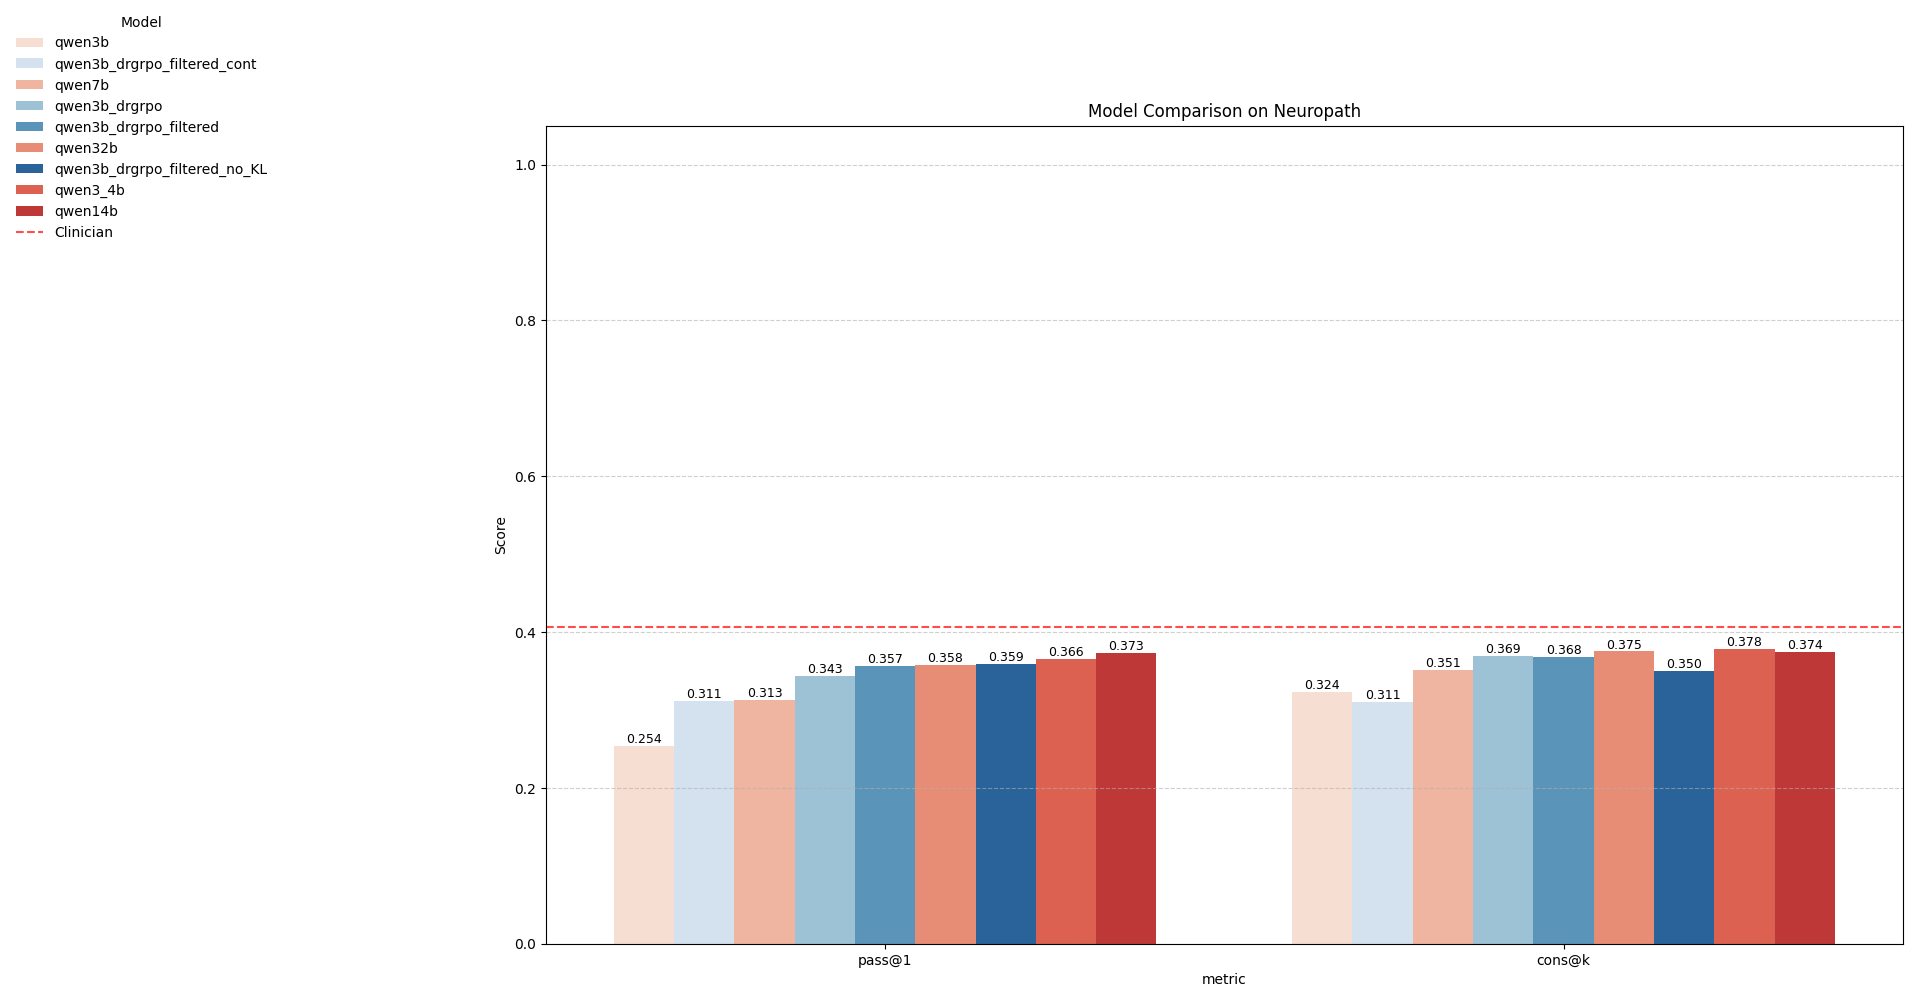

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.colors import to_rgba

# Define key models to highlight
key_models = [model for model in df_sorted['model'].unique() if "drgrpo" not in model]


clinician_df = df_sorted[df_sorted['model'] == 'clinician']
df_no_clinician = df_sorted[df_sorted['model'] != 'clinician']

# Get all unique models
all_models = df_no_clinician['model'].unique()


# Create custom palette
palette = {}

# Generate yellow gradient for key models
yellow_shades = sns.color_palette("Reds", len(key_models))
for model, color in zip(key_models, yellow_shades):
    palette[model] = color

# Generate blue gradient for other models
other_models = [m for m in all_models if m not in key_models]
blue_shades = sns.color_palette("Blues", len(other_models))
for model, color in zip(other_models, blue_shades):
    palette[model] = color

# Plot
plt.figure(figsize=(20, 10))
ax = sns.barplot(data=df_no_clinician, x='metric', y='score', hue='model', palette=palette)

# Add horizontal line(s) for clinician score
for metric in clinician_df['metric'].unique():
    clinician_score = clinician_df[clinician_df['metric'] == metric]['score'].values[0]
    ax.axhline(y=clinician_score, linestyle='--', color='red', alpha=0.7, label=f'Clinician')
    break

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Comparison on Neuropath")
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("np.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [1]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# # Reshape to long format if needed
# # df_melted = df_sorted.melt(id_vars='model', var_name='metric', value_name='score')

# # Separate clinician and others
# clinician_df = df_sorted[df_sorted['model'] == 'clinician']
# df_no_clinician = df_sorted[df_sorted['model'] != 'clinician']

# # Sort by metric if needed
# # df_no_clinician = df_no_clinician.sort_values(by='metric')

# plt.figure(figsize=(20, 10))
# ax = sns.barplot(data=df_no_clinician, x='metric', y='score', hue='model', palette="Blues")

# # Add horizontal line(s) for clinician score
# for metric in clinician_df['metric'].unique():
#     clinician_score = clinician_df[clinician_df['metric'] == metric]['score'].values[0]
#     ax.axhline(y=clinician_score, linestyle='--', color='red', alpha=0.7, label=f'Clinician')
#     break

# # Add value labels on top of each bar
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

# plt.ylim(0, 1.05)
# plt.ylabel("Score")
# plt.title("Model Comparison on Neuropath")
# plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)
# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()


In [99]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 5))
# ax = sns.barplot(data=df_sorted, x='metric', y='score', hue='model', palette="Blues")

# # Add value labels on top of each bar
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

# plt.ylim(0, 1.05)
# plt.ylabel("Score")
# # plt.title("Model Comparison on Cognitive Status")
# plt.title("Model Comparison on Neuropath")
# # plt.title("Model Comparison on Primary etiology")

# # Move legend outside to the top left
# plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)

# plt.grid(axis='y', linestyle='--', alpha=0.6)
# plt.tight_layout()
# # plt.savefig("cog_status.pdf", format='pdf', bbox_inches='tight', dpi=300)
# # plt.savefig("mci.pdf", format='pdf', bbox_inches='tight', dpi=300)
# plt.show()


In [118]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize


['Hello there!', 'How are you doing?', "I'm doing fine.", 'Thanks for asking.']


[nltk_data] Downloading package punkt to
[nltk_data]     /usr3/graduate/skowshik/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [134]:
text = "1. Hello there! How are you doing? I'm doing fine. Thanks for asking."
sentences = sent_tokenize(text)
print(sentences)
[s for s in sentences if not s.strip()[0].isdigit()]

['1.', 'Hello there!', 'How are you doing?', "I'm doing fine.", 'Thanks for asking.']


['Hello there!', 'How are you doing?', "I'm doing fine.", 'Thanks for asking.']

In [169]:
from langdetect import detect, detect_langs
from langdetect.lang_detect_exception import LangDetectException
import re
from collections import Counter

def split_into_sentences(text):
    # Basic sentence splitting by punctuation. You can use nltk for more accuracy.
    # sentences = re.split(r'(?<=[.!?])\s*', text.strip())
    sentences = sent_tokenize(text)
    return [s for s in sentences if not s.strip()[0].isdigit()]  # Remove empty strings

def detect_languages(text):
    sentences = split_into_sentences(text)
    language_counts = Counter()

    for sentence in sentences:
        # print(sentence)
        try:
            lang = detect(sentence)
            # print(sentence, lang)
            language_counts[lang] += 1
        except LangDetectException:
            language_counts['unknown'] += 1

    total = sum(language_counts.values())
    proportions = {lang: count / total for lang, count in language_counts.items()}

    return language_counts, proportions


In [176]:
# Example usage
# text = model_dfs['qwen3b'].iloc[0]['generated_text']
text = 'Hello, how are you? ' + '你好吗？'

print(detect_langs(text))
counts, proportions = detect_languages(text)

print("Language Counts:", counts)
print("Language Proportions:")
for lang, prop in proportions.items():
    print(f"{lang}: {prop:.2%}")

[en:0.7142836721791681, cy:0.2857150144084665]
Language Counts: Counter({'en': 1, 'zh-cn': 1})
Language Proportions:
en: 50.00%
zh-cn: 50.00%


In [ ]:
unknown = []
for i, row in model_dfs['qwen3b'].iterrows():
    text = row['generated_text']
    counts, proportions = detect_languages(text)
    if len(counts) != 1:
        # unknown.append(i)
        unknown.append((i, counts, proportions))
        # break

In [ ]:
unknown

In [192]:
import langid

def split_into_sentences(text):
    sentences = sent_tokenize(text)
    return [s for s in sentences if not s.strip()[0].isdigit()]  # Remove empty strings

def detect_languages(text):
    sentences = split_into_sentences(text)
    language_counts = Counter()

    for sentence in sentences:
        # print(sentence)
        try:
            lang, confidence = langid.classify(sentence)
            # print(sentence, lang)
            language_counts[lang] += 1
        except LangDetectException:
            language_counts['unknown'] += 1

    total = sum(language_counts.values())
    proportions = {lang: count / total for lang, count in language_counts.items()}

    return language_counts, proportions

In [ ]:
unknown = []
for i, row in model_dfs['qwen3b'].iterrows():
    text = row['generated_text']
    counts, proportions = detect_languages(text)
    unknown.append((i, counts, proportions))
    # break

In [194]:
unknown

[(0, Counter({'en': 10}), {'en': 1.0})]

In [191]:
import langid

text = "he patient's presentation suggests other cause of cognitive impairment as well."
lang, confidence = langid.classify(text)
print(f"Language: {lang}, Confidence: {confidence}")


Language: en, Confidence: -122.36210536956787


In [1]:
import pandas as pd

In [2]:
y = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/open-r1/logs/qwen25_3B_filtered_corrected_entropy.csv")
# y = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/open-r1/logs/qwen25_3B_filtered_no_kl_corrected.csv")

/scratch/5552643.1.cds-gpu-long/ipykernel_1695488/2943925536.py:1: DtypeWarning: Columns (0,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  y = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/open-r1/logs/qwen25_3B_filtered_corrected_entropy.csv")


In [3]:
len(y)

712946

In [22]:
cnt = []
for i, row in y.iterrows():
    if row['completion'].lower().count("again") >= 1:
        # print("The word 'wait' appears at least twice.", i)
        # print(row['completion'])
        # break
        cnt.append(i)
        
len(cnt)

15486

In [23]:
print(y.iloc[cnt[-1]]['completion'])

<think>
Since the patient does not show any positive symptoms related to other specific conditions such as those caused by TBI, psychiatric disorders (though slight depression), Vascular, Prion, Systemic and Environmental Factors, we will need to verify her cognition against baseline standards and consider specific cognitive testing.
Given that the neuropsychological tests indicated a performance above age-adjusted average cognitive scores, there must have been multiple cognitive domains not simply failing but showing above average. Trail Making tests reflect organizational skills, Boston Naming Test the ability to categorize or name objects, Digit Span assessing executive function and working memory and logical memory, and Mini-Mental State Examination a fair full exam.
The provided genetic testing information is also not suspicious for certain conditions like dementia-inducing genes such as CJD or Prion disease, and despite an existing history of depression or mild cognitive impairme

In [5]:
print(y.iloc[-1]['completion'])
print(y.iloc[-1]['correctness_reward'])

<think>
To address the scenario, let's delve in the provided results of the neuropsychological battery:
1. MMSE (24/30) - A score in the low end signifies an inability to perform high-level cognitive functions, but the test fails to rule out possible dementia in many cases.
2. Boston Naming Test (14/30) and Boston Visuospatial skills (intersecting pentagon, 0 point) fall substantially short of the typical scores, indicating language and visuospatial deficits.
3. Trail Making Test (3 errors within 1 minute) suggests some issue with neurocognitive processing speed,
4. General information shows severe depression based on GDS score.
5. Activities of daily life (FAS) suggest a functional profile that remains within a relatively normal range; she can manage finances, shopping and cooking.
6. UPDRS: No signs of Parkinson's disease symptoms, ruling out Parkinson's.
The APOE e3/e3 carrier reveals her not to be a high-risk for AD. Further analysis would consider a dementia diagnosis, but we have